<a href="https://colab.research.google.com/github/AileenLavelle/PBC_Object_Detection/blob/main/Boca_nomask_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import json
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import cv2
import matplotlib.pyplot as plt

!pip install sahi ultralytics
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel

Loading the Yolovn model

In [13]:
# YOLOv11 model
model_path = "yolo11x.pt"

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=model_path,
    confidence_threshold=0.3,
    device="cuda:0"
)

In [ ]:
Just Yolo on its own

In [14]:
# Load YOLOv11 model
model = YOLO("yolo11x.pt")

# Setup paths
image_folder = "/content/Boca_Raton"
output_folder = "/content/Boca_Raton/output_yolo11x"
os.makedirs(output_folder, exist_ok=True)
ground_truth_json = "/content/Boca_Raton/_annotations.coco.json"

with open(ground_truth_json) as f:
    gt = json.load(f)
# Re-generate predictions with correct category ID
predictions = []

for img_data in tqdm(gt['images'], desc="Processing images"):
    img_path = os.path.join(image_folder, img_data['file_name'])

    if not os.path.exists(img_path):
        continue

    # Change device from 'cuda:0' to 'cpu' as no GPU is available.
    results = model(img_path, conf=0.3, device='cpu', verbose=False)

    for result in results:
        boxes = result.boxes
        for i in range(len(boxes)):
            class_id = int(boxes.cls[i])
            # YOLO class 8 = boat in COCO, map to your category ID 1
            if class_id == 8:
                xyxy = boxes.xyxy[i].cpu().numpy()
                conf = float(boxes.conf[i])
                bbox = [float(xyxy[0]), float(xyxy[1]),
                        float(xyxy[2] - xyxy[0]), float(xyxy[3] - xyxy[1])]

                predictions.append({
                    "image_id": img_data['id'],
                    "category_id": 1,  # Changed from 8 to 1
                    "bbox": bbox,
                    "score": conf
                })

# Save and evaluate
pred_json = os.path.join(output_folder, "predictions.json")
with open(pred_json, 'w') as f:
    json.dump(predictions, f)

coco_gt = COCO(ground_truth_json)
coco_dt = coco_gt.loadRes(predictions) if predictions else coco_gt.loadRes([])

coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.params.catIds = [1]  # Evaluate category ID 1 (Boat)
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

print(f"\nTotal predictions: {len(predictions)}")
print(f"mAP@0.5:0.95: {coco_eval.stats[0]:.3f}")
print(f"mAP@0.5: {coco_eval.stats[1]:.3f}")

Processing images: 100%|██████████| 46/46 [02:56<00:00,  3.83s/it]

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.065
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.067
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.481
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.700
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.057
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

SAHI & Yolo

In [15]:
!pip install sahi
from sahi.predict import get_sliced_prediction
from sahi import AutoDetectionModel

# Setup SAHI model
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path="yolo11x.pt",
    confidence_threshold=0.3,
    device="cuda:0"
)

predictions_sahi = []

for img_data in tqdm(gt['images'], desc="Processing with SAHI"):
    img_path = os.path.join(image_folder, img_data['file_name'])
    if not os.path.exists(img_path):
        continue

    result = get_sliced_prediction(
        img_path,
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    for obj in result.object_prediction_list:
        if obj.category.id == 8:  # YOLO boat class
            bbox = obj.bbox
            predictions_sahi.append({
                "image_id": img_data['id'],
                "category_id": 1,  # Your boat category
                "bbox": [bbox.minx, bbox.miny, bbox.maxx - bbox.minx, bbox.maxy - bbox.miny],
                "score": obj.score.value
            })

# Evaluate SAHI results
coco_dt_sahi = coco_gt.loadRes(predictions_sahi)
coco_eval_sahi = COCOeval(coco_gt, coco_dt_sahi, 'bbox')
coco_eval_sahi.params.catIds = [1]
coco_eval_sahi.evaluate()
coco_eval_sahi.accumulate()
coco_eval_sahi.summarize()

print(f"\nSAHI Total predictions: {len(predictions_sahi)} (baseline: 36)")



# 1. Check what's being missed - visualize false negatives
import cv2
from PIL import Image

# Get ground truth boats
gt_boats = [ann for ann in gt['annotations'] if ann['category_id'] == 1]
pred_image_ids = set(p['image_id'] for p in predictions)
gt_image_ids = set(ann['image_id'] for ann in gt_boats)

print(f"Images with GT boats: {len(gt_image_ids)}")
print(f"Images with predictions: {len(pred_image_ids)}")
print(f"Images with boats but no predictions: {len(gt_image_ids - pred_image_ids)}")
print(f"\nTotal GT boats: {len(gt_boats)}")
print(f"Total predictions: {len(predictions)}")

Processing with SAHI:   0%|          | 0/46 [00:00<?, ?it/s]

Performing prediction on 1 slices.


Processing with SAHI:   2%|▏         | 1/46 [00:04<03:28,  4.63s/it]

Performing prediction on 1 slices.


Processing with SAHI:   4%|▍         | 2/46 [00:08<02:52,  3.93s/it]

...

Performing prediction on 1 slices.


Processing with SAHI:  98%|█████████▊| 45/46 [02:44<00:03,  3.68s/it]

Performing prediction on 1 slices.


Processing with SAHI: 100%|██████████| 46/46 [02:48<00:00,  3.66s/it]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.062
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.096
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.067
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.048
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.491
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.053
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.075
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.075
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

I want to see where the annotations are

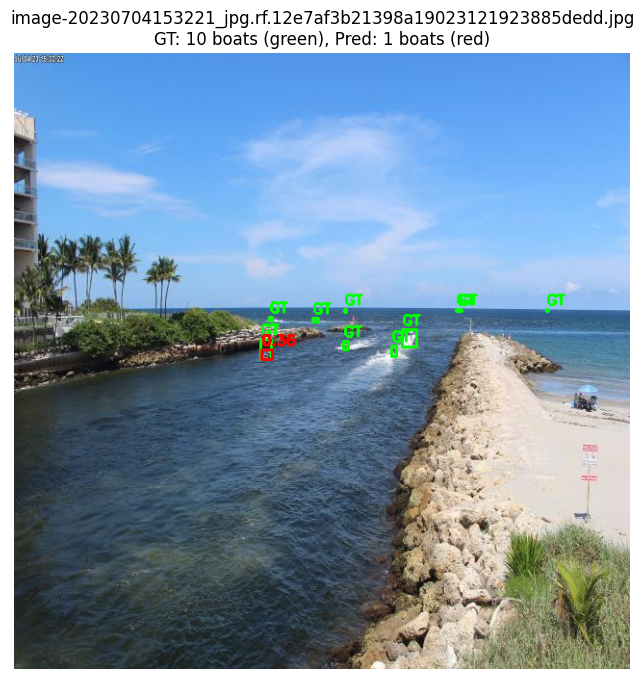

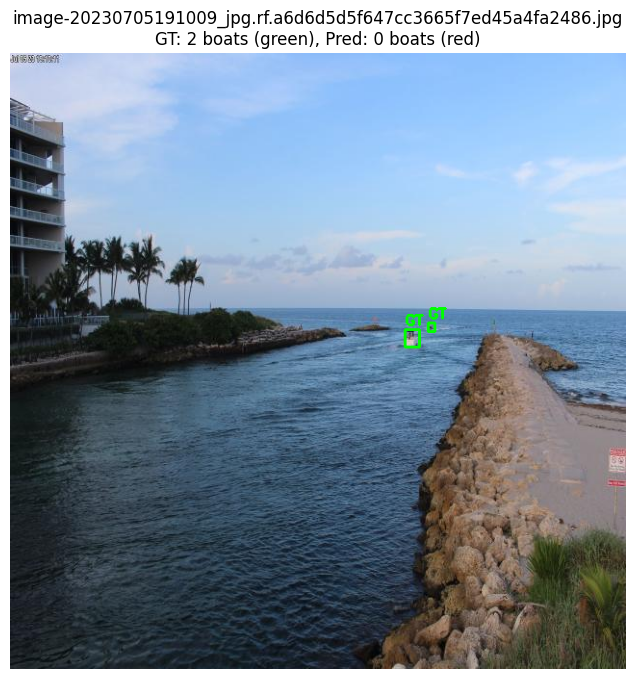

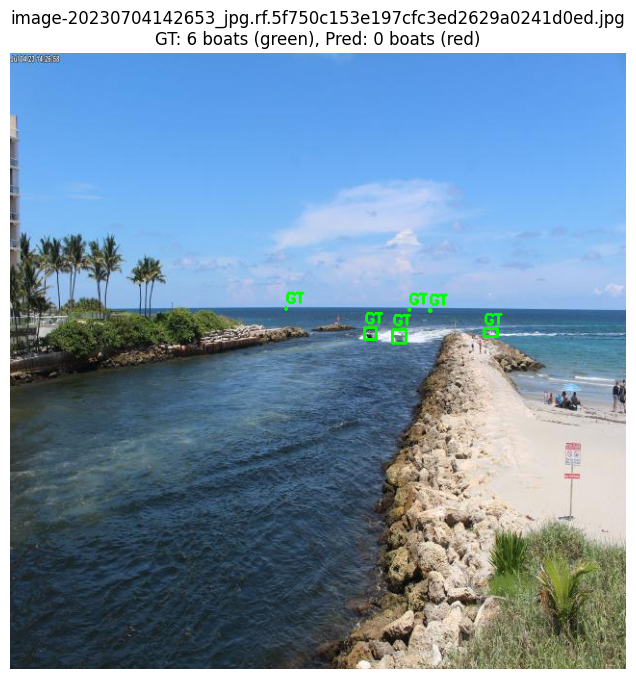

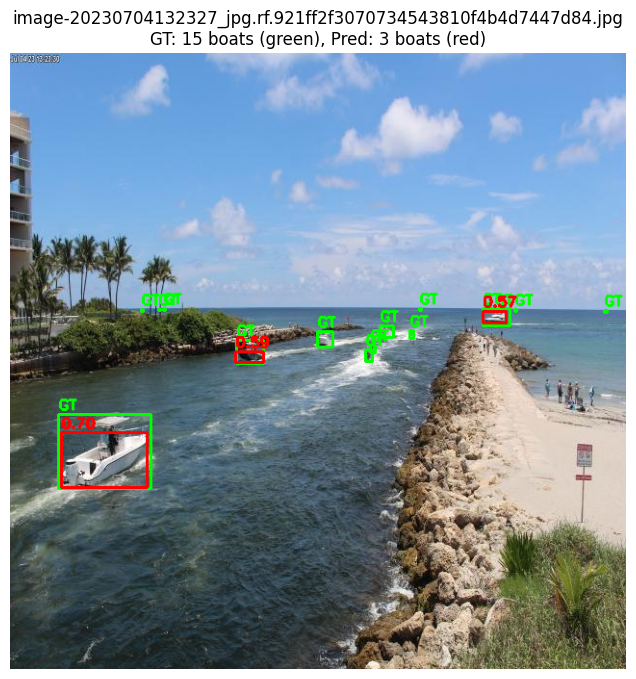

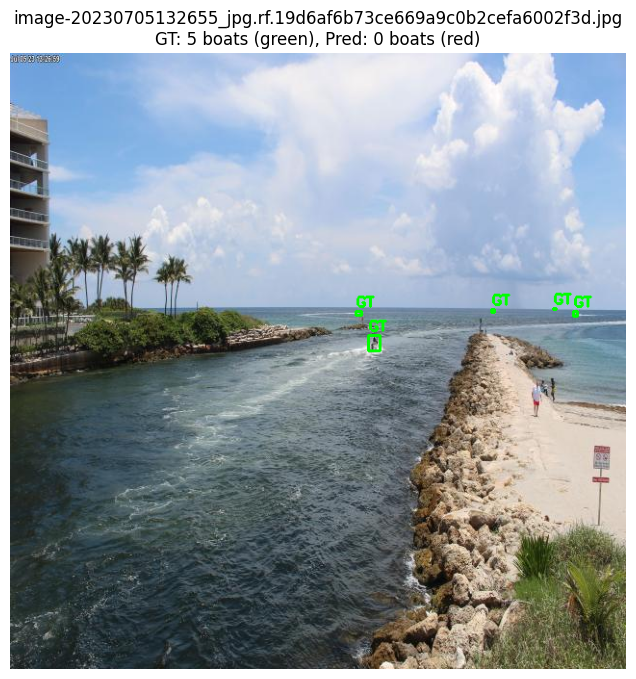

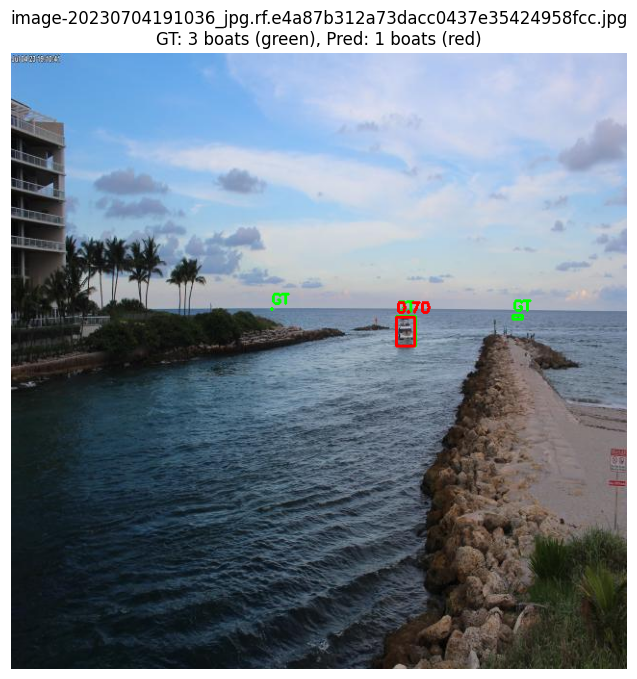

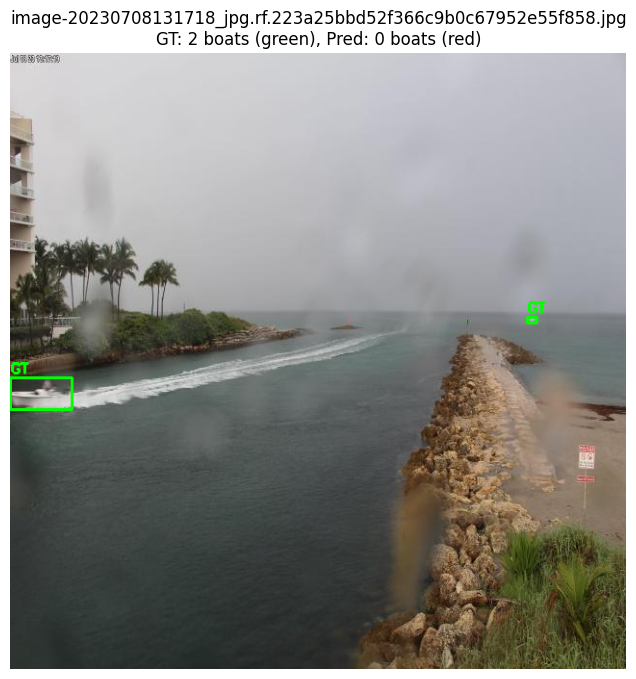

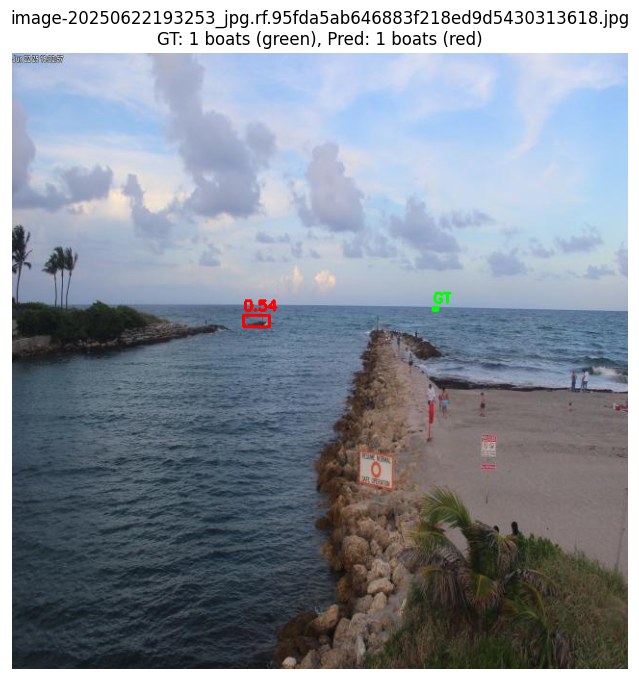

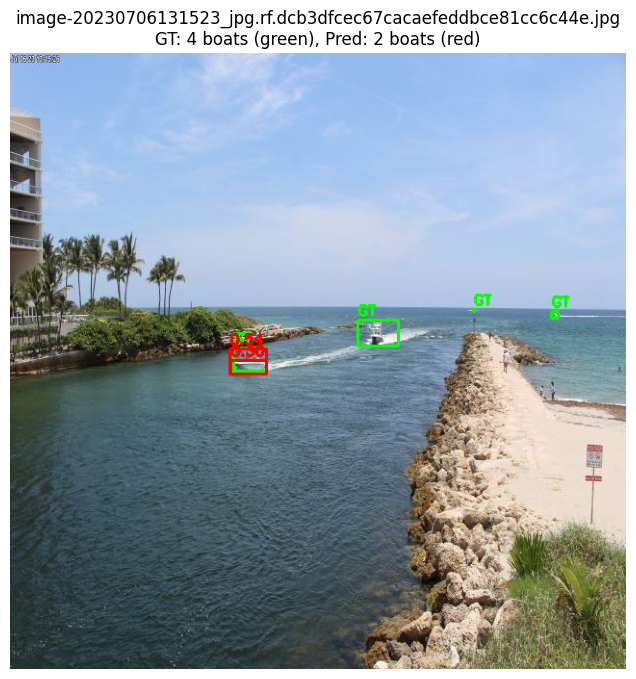

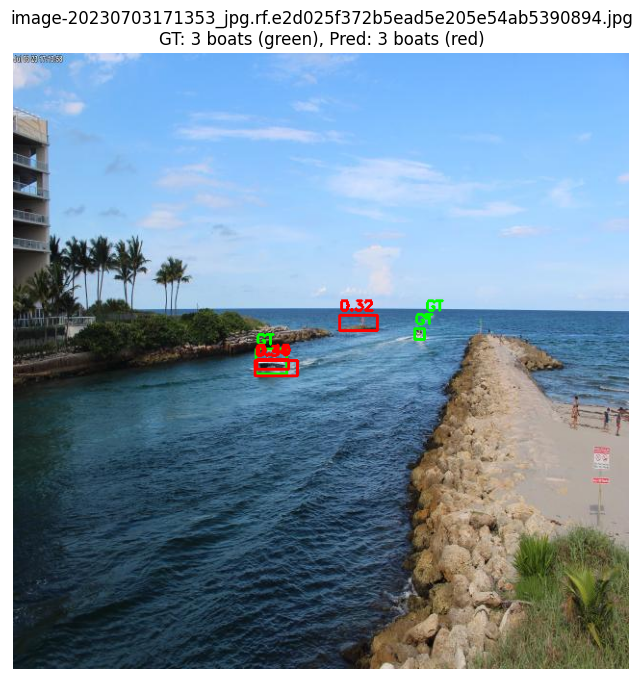

Visualizations saved to: /content/Boca_Raton/output_yolo11/visualizations


In [12]:
# Create visualization folder
vis_folder = os.path.join(output_folder, "visualizations")
os.makedirs(vis_folder, exist_ok=True)

# Group predictions by image
from collections import defaultdict
pred_by_image = defaultdict(list)
for pred in predictions:
    pred_by_image[pred['image_id']].append(pred)

# Group GT by image
gt_by_image = defaultdict(list)
for ann in gt['annotations']:
    if ann['category_id'] == 1:  # Boat category
        gt_by_image[ann['image_id']].append(ann)

# Visualize first 10 images
id_to_filename = {img['id']: img['file_name'] for img in gt['images']}

for img_id in list(gt_by_image.keys())[:10]:  # First 10 images with GT boats
    img_path = os.path.join(image_folder, id_to_filename[img_id])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw ground truth in GREEN
    for ann in gt_by_image[img_id]:
        x, y, w, h = [int(v) for v in ann['bbox']]
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, 'GT', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Draw predictions in RED
    for pred in pred_by_image[img_id]:
        x, y, w, h = [int(v) for v in pred['bbox']]
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(img, f"{pred['score']:.2f}", (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"{id_to_filename[img_id]}\nGT: {len(gt_by_image[img_id])} boats (green), Pred: {len(pred_by_image[img_id])} boats (red)")
    plt.axis('off')

    # Save
    save_path = os.path.join(vis_folder, id_to_filename[img_id])
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

print(f"Visualizations saved to: {vis_folder}")